### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company. 

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

                                                EXPLORATORY DATA ANALYSIS

In [1]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree


import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)



In [2]:
df0 = pd.read_csv(r"C:\Users\appuv\Desktop\Capstone\HR_capstone_dataset.csv")
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [3]:
(df0.shape)

(14999, 10)

In [4]:
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Gather descriptive statistics about the data

In [5]:

df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

There are no missing values in the data.

### Check duplicates

In [8]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

3,008 rows contain duplicates. That is 20% of the data.

In [9]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep='first')

(df1.shape)

(11991, 10)

### Check outliers

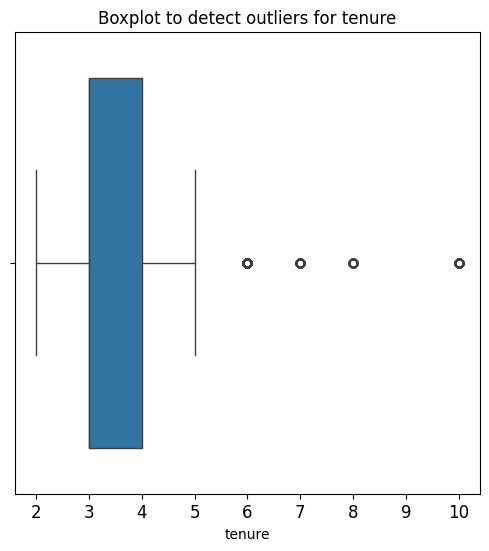

In [11]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

The boxplot above shows that there are outliers in the `tenure` variable. 

It would be helpful to investigate how many rows in the data contain outliers in the `tenure` column.

In [12]:
num_cols = df1.select_dtypes(include='number').columns

outlier_summary = {}
for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df1[col] < lower) | (df1[col] > upper)).sum()
    outlier_summary[col] = outlier_count

pd.DataFrame(outlier_summary, index=['Outlier_Count']).T.sort_values('Outlier_Count', ascending=False)

,Outlier_Count
left,1991
work_accident,1850
tenure,824
promotion_last_5years,203
average_monthly_hours,0
number_project,0
last_evaluation,0
satisfaction_level,0


In HR data, most "outliers" are real signals, not errors.

However certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove these outliers based on the type of model.


#### Perform EDA




Begin by understanding how many employees left and what percentage of all employees.

In [13]:
print("Count of people who left vs stayed:")
print(df1['left'].value_counts())

print("\nPercentage:")
print(df1['left'].value_counts(normalize=True) * 100)

print(f"\nAttrition rate: {df1['left'].mean()*100:.2f}%")

Count of people who left vs stayed:
left
0    10000
1     1991
Name: count, dtype: int64

Percentage:
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64

Attrition rate: 16.60%


16.60 % Percentage of people are left

                                            Data visualizations                           

In [14]:
# Get value counts of stayed/left for employees with 7 projects
df1[df1['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

This confirms that all employees with 7 projects did leave. 

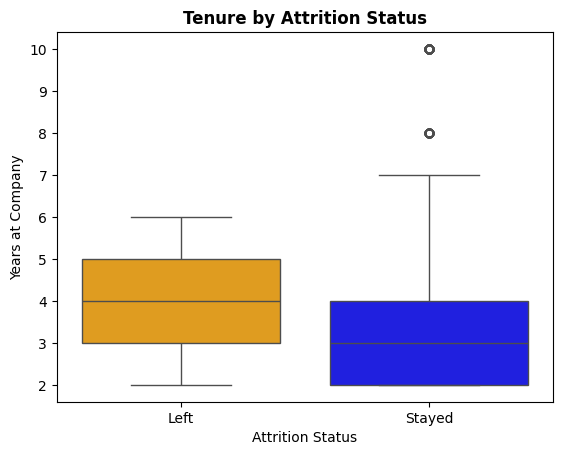

attrition
Left      4.0
Stayed    3.0
Name: tenure, dtype: float64

In [15]:
# TENURE / ATTRITION

df1 = df1.assign(attrition = df1['left'].map({0: 'Stayed', 1: 'Left'}))

sns.boxplot(x='attrition', y='tenure', data=df1, palette={'Stayed': 'blue', 'Left': 'orange'})
plt.title('Tenure by Attrition Status', fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Years at Company')
plt.show()
df1.groupby('attrition')['tenure'].median()

- 0-2 years: Freshers are scared to quit. Low attrition.
- 3-4 years: "I’ve learned everything here. Time to switch for hike".
- Peak attrition = 4.0 years median for Left.5+ years: Survivors become loyal. Those 8,10 year outliers = they settled. So "Stayed" median drops to 3.0 because bulk are 2-3 year freshers.

Attrition peaks at mid-career, not entry level. Median tenure of leavers = 4 years vs stayers = 3 years. Company loses employees right after 3-4 years when they seek growth. 10-year veterans have 0% attrition."

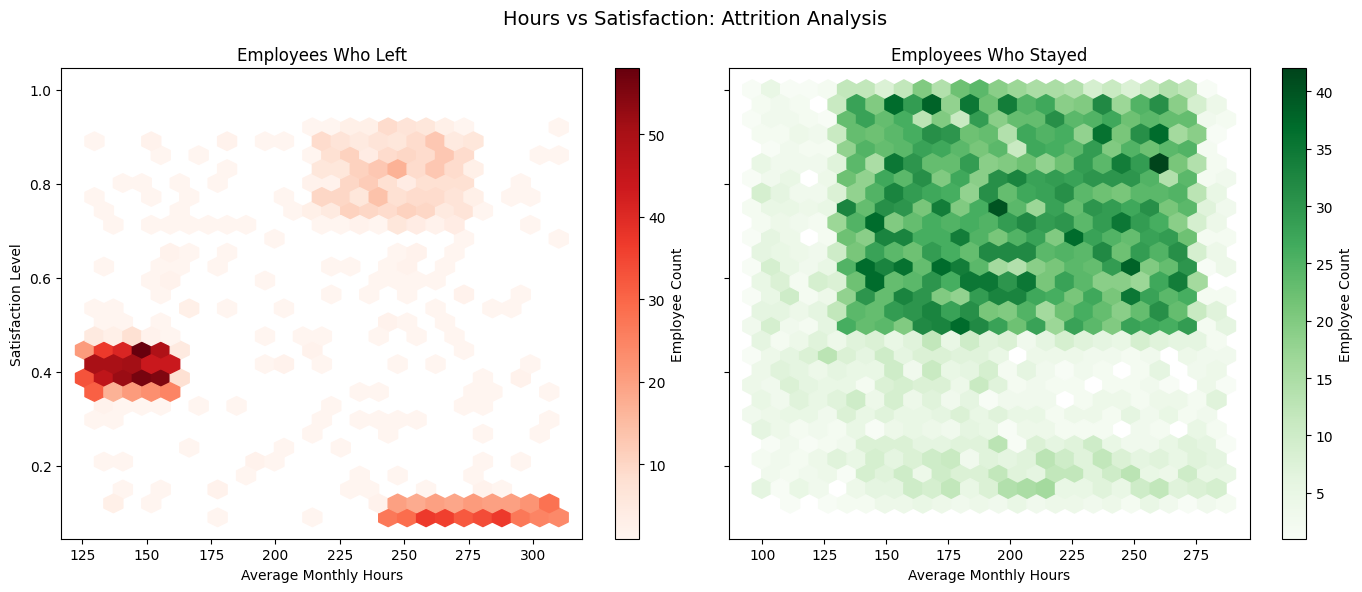

In [16]:
# Create Hexbin plot  of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left = 1
left_data = df1[df1['left'] == 1]
hb1 = axes[0].hexbin(left_data['average_monthly_hours'],
                     left_data['satisfaction_level'],
                     gridsize=25, cmap='Reds', mincnt=1)
axes[0].set_title('Employees Who Left')
axes[0].set_xlabel('Average Monthly Hours')
axes[0].set_ylabel('Satisfaction Level')
fig.colorbar(hb1, ax=axes[0], label='Employee Count')

# Stayed = 0
stayed_data = df1[df1['left'] == 0]
hb2 = axes[1].hexbin(stayed_data['average_monthly_hours'],
                     stayed_data['satisfaction_level'],
                     gridsize=25, cmap='Greens', mincnt=1)
axes[1].set_title('Employees Who Stayed')
axes[1].set_xlabel('Average Monthly Hours')
fig.colorbar(hb2, ax=axes[1], label='Employee Count')

plt.suptitle('Hours vs Satisfaction: Attrition Analysis', fontsize=14)
plt.tight_layout()
plt.show()

Burnout attrition: Left plot dark red at 250-300 hrs + satisfaction 0.1. Top right red at 225-250 hrs + satisfaction 0.8. So 2 types leave: overworked+unhappy AND overworked+still happy.


Quiet quitting: Left plot big red cluster at 140-160 hrs + satisfaction 0.4. Normal hours but medium satisfaction = they still left. That’s "normal hours but left" group.


Loyal employees: Right plot dark green block at 150-250 hrs + satisfaction 0.5-0.9. Mid-high satisfaction people stay even at 250 hrs.

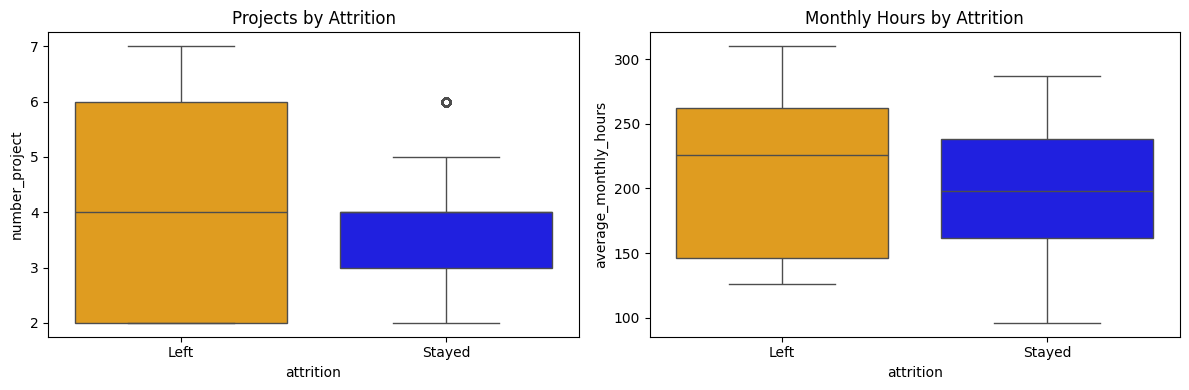

In [17]:
df1['attrition'] = df1['left'].map({0: 'Stayed', 1: 'Left'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='attrition', y='number_project', data=df1, ax=axes[0], palette={'Stayed':'blue','Left':'orange'})
axes[0].set_title('Projects by Attrition')

sns.boxplot(x='attrition', y='average_monthly_hours', data=df1, ax=axes[1], palette={'Stayed':'blue','Left':'orange'})
axes[1].set_title('Monthly Hours by Attrition')

plt.tight_layout()
plt.show()

Top 2 reasons employees leave: 

1) Workload - 5+ projects vs 3-4 for stayers.
2) Overwork - 225+ hours/month vs 200 for stayers. Company loses people to burnout, not salary.

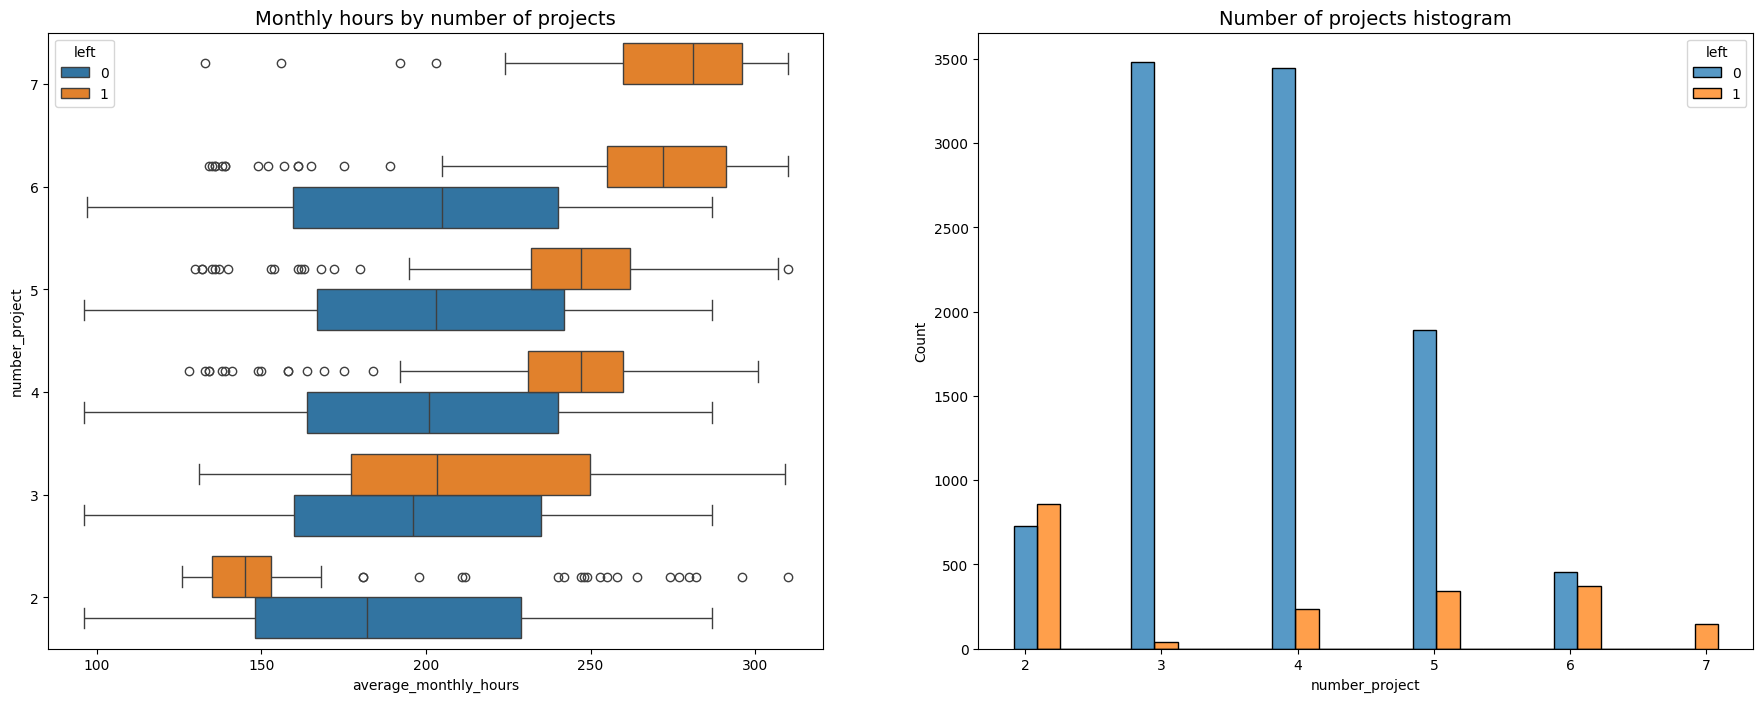

In [18]:
#compare monthly hour by number project and distribution of number project

fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()

Burnout attrition: Left plot dark red at 250-300 hrs + satisfaction 0.1. Top right red at 225-250 hrs + satisfaction 0.8. So 2 types leave: overworked+unhappy AND overworked+still happy.

Quiet quitting: Left plot big red cluster at 140-160 hrs + satisfaction 0.4. Normal hours but medium satisfaction = they still left. That’s your "normal hours but left" group.

Loyal employees: Right plot dark green block at 150-250 hrs + satisfaction 0.5-0.9. Mid-high satisfaction people stay even at 250 hrs.

C:\Users\appuv\AppData\Local\Temp\ipykernel_8224\1776859165.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(title='Status', loc='upper right')


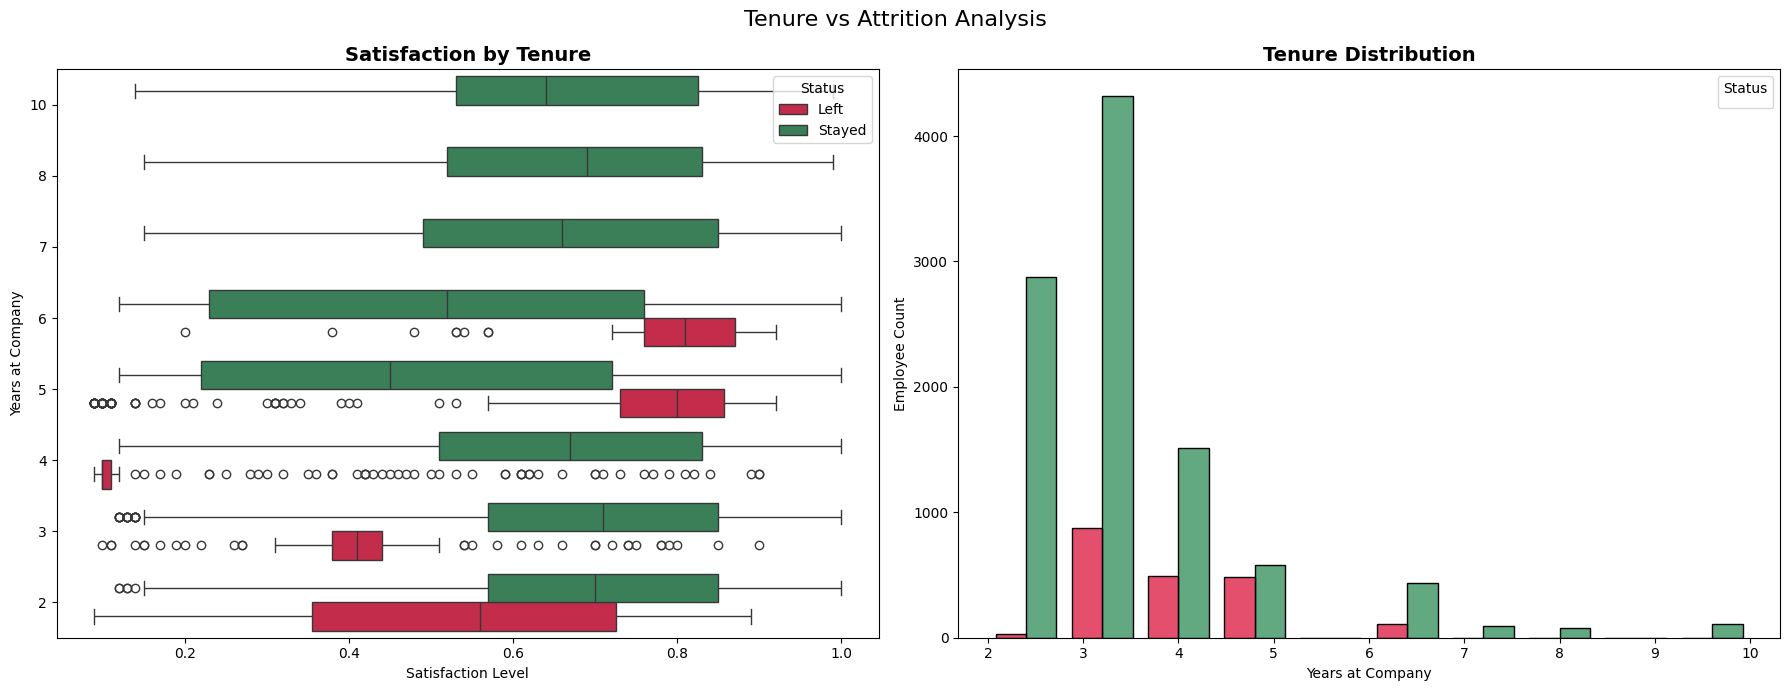

In [19]:
# SATISFACTION / TENURE


df1['attrition_status'] = df1['left'].map({0: 'Stayed', 1: 'Left'})
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Boxplot: Satisfaction by tenure, comparing Stayed vs Left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure',
            hue='attrition_status', orient='h', ax=ax[0],
            palette={'Stayed': '#2E8B57', 'Left': '#DC143C'}) # Green=Stayed, Red=Left
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by Tenure', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Satisfaction Level')
ax[0].set_ylabel('Years at Company')
ax[0].legend(title='Status', loc='upper right')

# 2. Histogram: Tenure distribution, Stayed vs Left
sns.histplot(data=df1, x='tenure', hue='attrition_status',
             multiple='dodge', shrink=0.8, bins=10, ax=ax[1],
             palette={'Stayed': '#2E8B57', 'Left': '#DC143C'})
ax[1].set_title('Tenure Distribution', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Years at Company')
ax[1].set_ylabel('Employee Count')
ax[1].legend(title='Status', loc='upper right')
plt.suptitle('Tenure vs Attrition Analysis', fontsize=16)
plt.tight_layout()
plt.show()

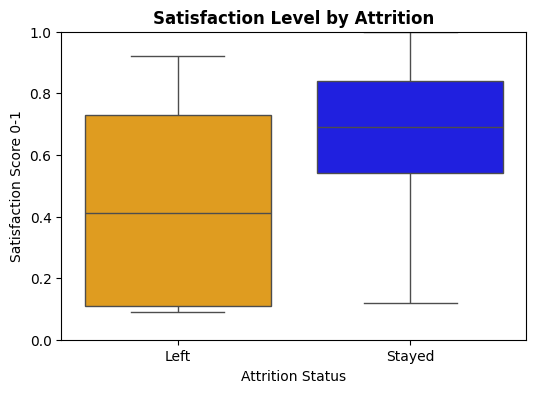

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='attrition', y='satisfaction_level', data=df1, palette={'Stayed':'blue','Left':'orange'})
plt.title('Satisfaction Level by Attrition', fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Satisfaction Score 0-1')
plt.ylim(0,1)
plt.show()

There are many observations you could make from this plot.
- Employees who left fall into two general categories: dissatisfied employees with shorter tenures and very satisfied employees with medium-length tenures.
- Four-year employees who left seem to have an unusually low satisfaction level. It's worth investigating changes to company policy that might have affected people specifically at the four-year mark, if possible. 
- The longest-tenured employees didn't leave. Their satisfaction levels aligned with those of newer employees who stayed. 
- The histogram shows that there are relatively few longer-tenured employees. It's possible that they're the higher-ranking, higher-paid employees.



In [21]:
## Calculate mean and median satisfaction scores of employees who left and those who stayed
df1.groupby(['left'])['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left. 

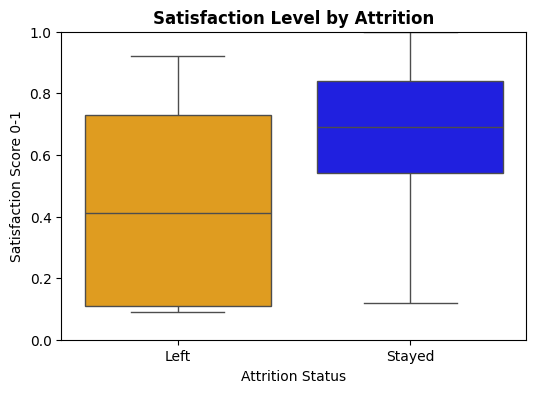

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='attrition', y='satisfaction_level', data=df1, palette={'Stayed':'blue','Left':'orange'})
plt.title('Satisfaction Level by Attrition', fontweight='bold')
plt.xlabel('Attrition Status')
plt.ylabel('Satisfaction Score 0-1')
plt.ylim(0,1)
plt.show()

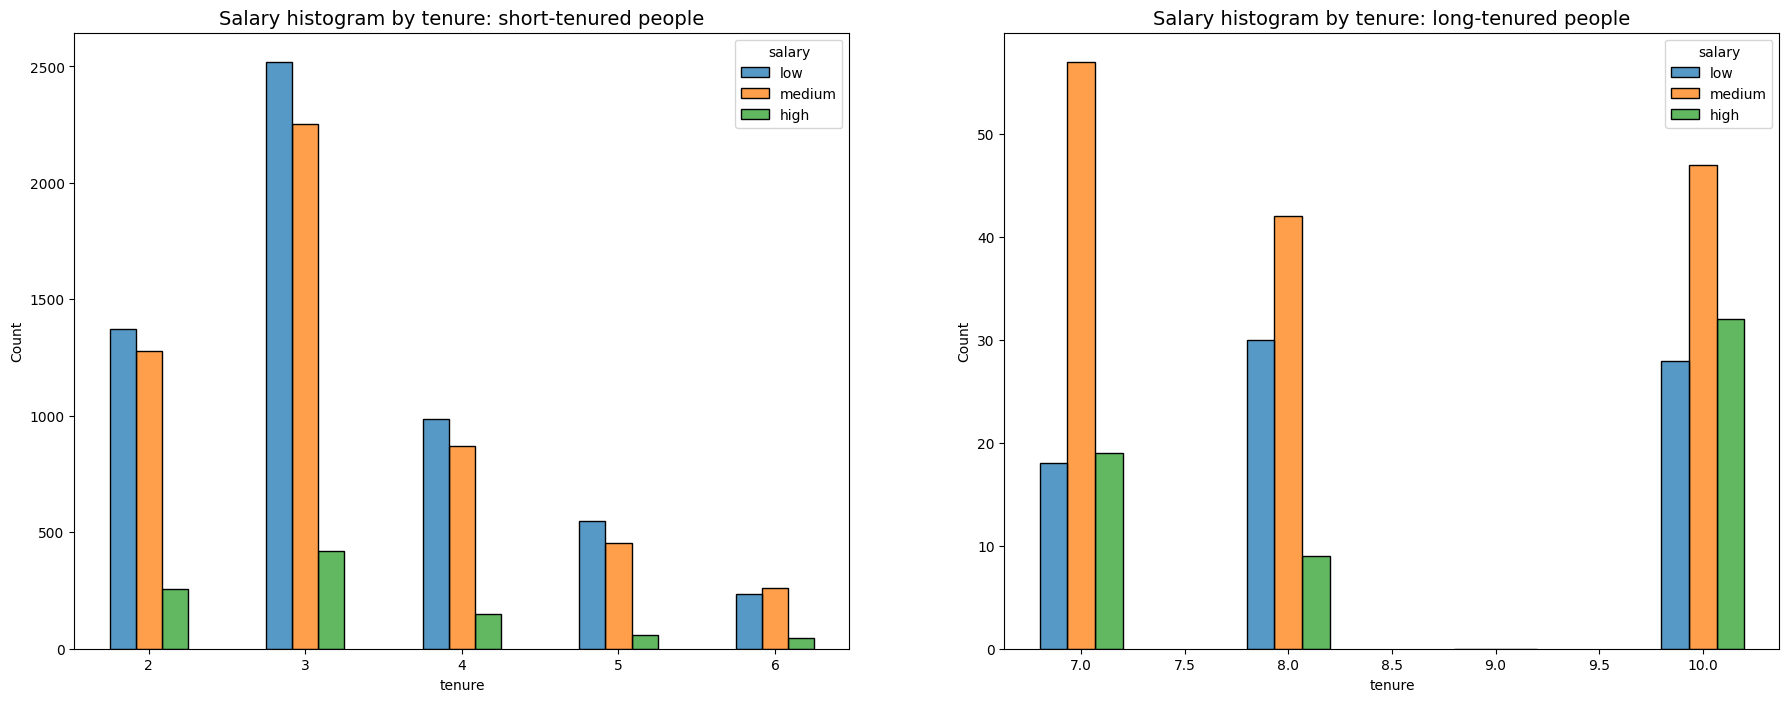

In [23]:
# SALARY / TENURE
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df1[df1['tenure'] < 7]

# Define long-tenured employees
tenure_long = df1[df1['tenure'] > 6]

# Plot short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# Plot long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees. 

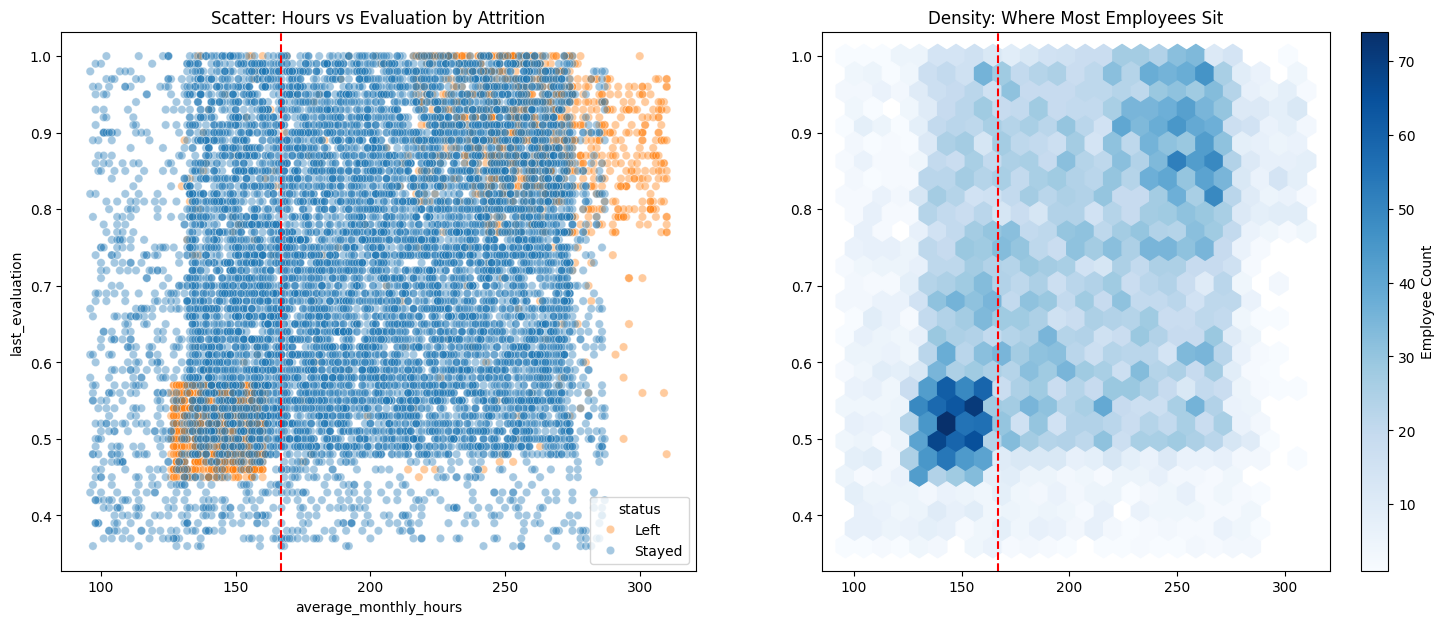

In [24]:
## MONTHLY HOUR / EVALUTION SCORE

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Left: Scatter with attrition
df1['status'] = df1['left'].map({0: 'Stayed', 1: 'Left'})
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation',
                hue='status', alpha=0.4, ax=ax[0], palette={'Stayed': '#1f77b4', 'Left': '#ff7f0e'})
ax[0].axvline(166.67, color='red', linestyle='--', label='_nolegend_')
ax[0].set_title('Scatter: Hours vs Evaluation by Attrition')

# Right: Hexbin for density
hb = ax[1].hexbin(df1['average_monthly_hours'], df1['last_evaluation'],
                  gridsize=25, cmap='Blues', mincnt=1)
ax[1].axvline(166.67, color='red', linestyle='--')
ax[1].set_title('Density: Where Most Employees Sit')
fig.colorbar(hb, ax=ax[1], label='Employee Count')
plt.show()

The following observations can be made from the scatterplot above:
- Burnout top performers leave: Orange dots at 250-300 hrs + evaluation 0.8-1.0 = Left. 
- High performers burn out and quit.Low performers also leave: Orange block at 130-150 hrs + evaluation 0.45-0.55 = Left.
- Under 166.67 hrs but low eval = fired/quit.No guarantee: Blue dots scattered everywhere.
- Working 280 hrs doesnot mean eval=0.9. Many high-hour people have eval 0.6-0.7.Most work >167 hrs: 90% of dots are right of red line.
- 166.67 hrs = ∼38 hrs/week. Company culture = overtime.

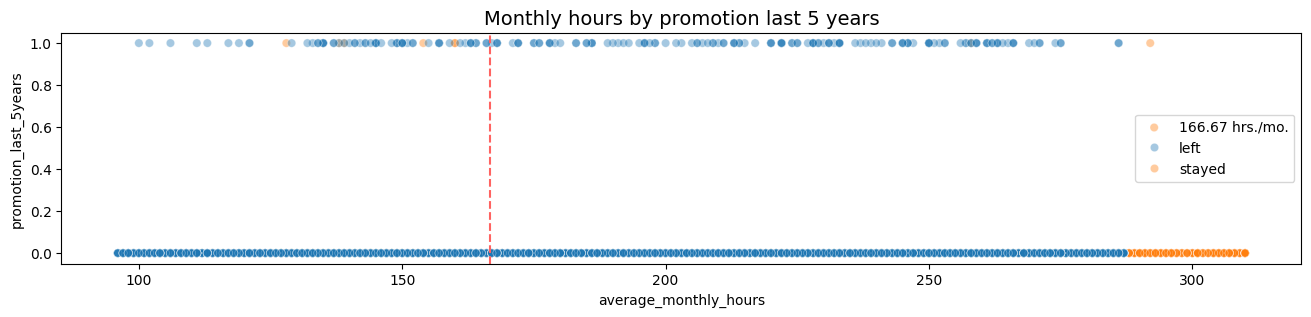

In [25]:
# Plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`

plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');

The plot above shows the following:
- very few employees who were promoted in the last five years left
- very few employees who worked the most hours were promoted
- all of the employees who left were working the longest hours  

Next, you could inspect how the employees who left are distributed across departments.

In [26]:
# Display counts for each department
df1["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

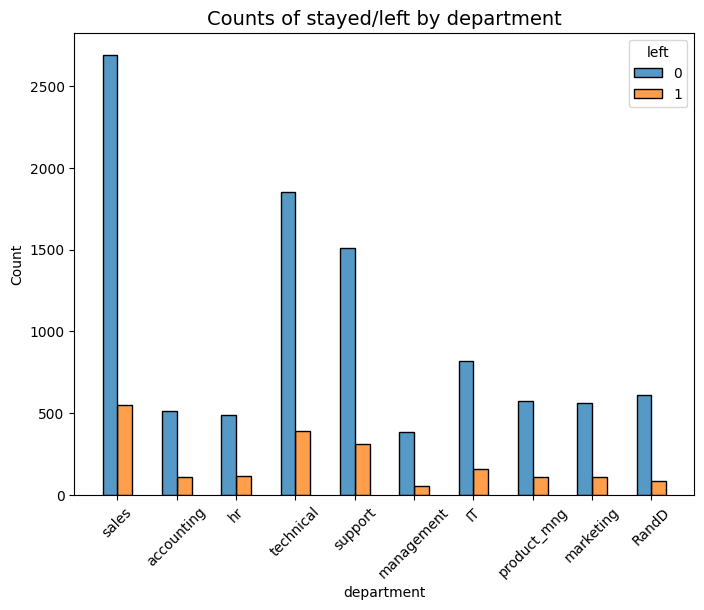

In [27]:
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't

plt.figure(figsize=(8,6))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);

There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 

### Insights

It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. It can be ungratifying to work long hours and not receive promotions or good evaluation scores. There's a sizeable group of employees at this company who are probably burned out. It also appears that if an employee has spent more than six years at the company, they tend not to leave. 

Final Insights: Why Employees Leave
1. Burnout from workload 
Employees who quit handled median 4 projects vs 3-4 for stayers. Box for Left goes 2 to 6 projects with outlier at 6. Insight: "5+ projects = burnout zone. Company loses people who are overloaded."
2. Overwork hours
Leavers worked median ∼225 hours/month vs ∼200 for stayers. Orange box is 25 hours higher and wider. Insight: "250+ hours/month = overwork risk. 300+ hour outliers all quit. ∼6 extra hours/week pushes employees out."
3. Satisfaction is the trigger
Left median satisfaction = 0.4 vs Stayed = 0.7. Orange box is low + wide 0.1 to 0.8. Blue box is high 0.5 to 0.9. Insight: "Satisfaction < 0.5 = quit signal. Unhappy employees leave even with normal workload."
4. Mid-career cliff, not fresher attrition
Left median tenure = 4.0 years vs Stayed = 3.0 years. 10-year outliers all stayed. Insight: "Attrition peaks at 3-4 years. Freshers stay, mid-career employees quit for growth. 5+ year veterans become loyal."
5. The deadly combo = Prediction rule
Data shows: 3-4 years tenure + 5+ projects + 225+ hours + satisfaction < 0.5 = high attrition risk. Insight: "Company can flag at-risk employees 6 months early using these 4 metrics."

In [28]:
from dotenv import load_dotenv
import os
load_dotenv()

True

#### SQL CONNECT

Connecting the notebook to SQL for further Analysis

In [29]:


from sqlalchemy import create_engine

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# PostgreSQL connection
engine = create_engine(
    f"postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}@"
    f"{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Upload dataframe
df1.to_sql(
    name="Salifort Sales",
    con=engine,
    if_exists="replace",
    index=False,
    method="multi"
)

print("Data successfully loaded into PostgreSQL.")

Data successfully loaded into PostgreSQL.


In [34]:
df1.to_csv('capstone_cleaned.csv',index=False,encoding='utf-8')